## Simulation--1 iteration
with graphs:
1. change of capital against time
2. change in number of active customers and accumulated claims against time

In [84]:
import numpy as np

np.random.seed(123)
# initialization
initial_capital = 2
premium_rate = 0.1
arrival_rate = 0.5
max_time = 20
claim_amt = 0.4
claim_rate = 0.3

# 1 single iteration
t = 0
capital = initial_capital
next_claim = np.random.exponential(1 / claim_rate)
next_arrive = np.random.exponential(1 / arrival_rate)
ls_cap = [capital]
ls_claim = [0]
ls_arrive = [0]
ls_time = [0]  # Tracking time steps for plotting later

while True:
    if t > max_time:
        break
    elif capital<0:
        ls_cap.append(capital)
        break
    elif next_arrive < next_claim:  # a new customer comes
        t += next_arrive

        # Accumulate premium capital, proportional to number of customers
        capital += premium_rate*next_arrive*(ls_arrive[-1])
        # Adjist interarrival time
        next_claim -= next_arrive
        # Generate new waiting time for the next customer arrival
        next_arrive = np.random.exponential(1/arrival_rate)
        ls_cap.append(capital)
        ls_claim.append(ls_claim[-1])
        ls_time.append(t)
        ls_arrive.append(ls_arrive[-1] + 1)

    else:  # a claim occurs
        t += next_claim
        capital += premium_rate*next_claim*(ls_arrive[-1])
        #suppose the person who claims the money no longer stays
        capital -= claim_amt
        # Adjust the interarrival time
        next_arrive -= next_claim
        # Generate new waiting time for the next claim occurrence
        next_claim = np.random.exponential(1 / claim_rate)
        # Log state changes
        ls_cap.append(capital)
        ls_claim.append(ls_claim[-1] + 1)
        ls_time.append(t)
        ls_arrive.append(ls_arrive[-1] -1)

print(f"Final Capital: {capital}")
print(f"Total Arrivals: {ls_arrive[-1]}")
print(f"Total Claims: {ls_claim[-1]}")


Final Capital: 2.6159657614308927
Total Arrivals: 3
Total Claims: 8


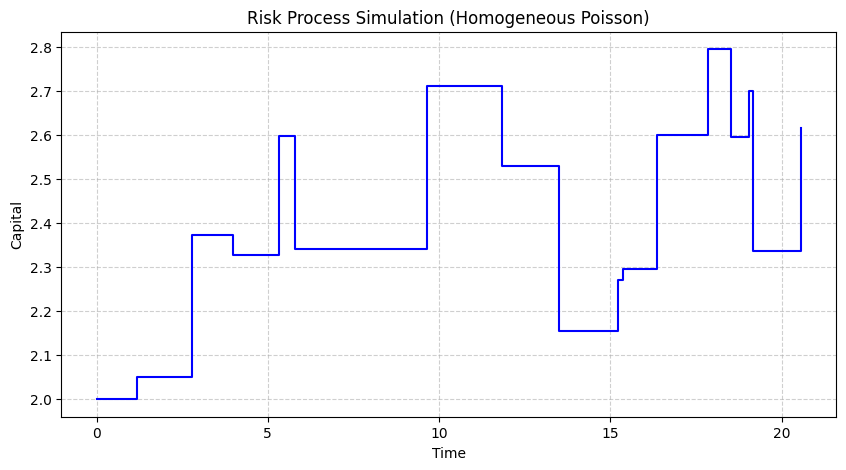

In [85]:

#Change in capital against time
plt.figure(figsize=(10, 5))
plt.step(ls_time, ls_cap, where='post', color='blue', linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Capital")
plt.title("Risk Process Simulation (Homogeneous Poisson)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


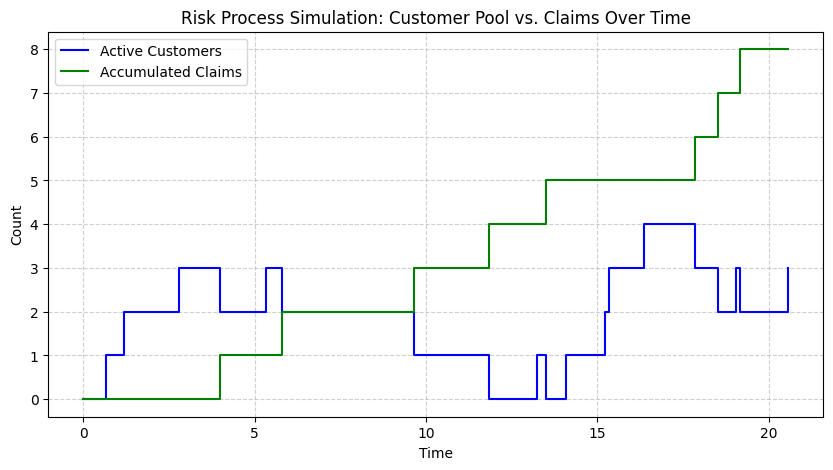

In [86]:
# Number of arrivals and Number of claims
plt.figure(figsize=(10, 5))

# 1. Add labels to the step lines
plt.step(ls_time, ls_arrive, where='post', color='blue', linewidth=1.5, label='Active Customers')
plt.step(ls_time, ls_claim, where='post', color='green', linewidth=1.5, label='Accumulated Claims')

plt.xlabel("Time")
# Fixed to 'Count' since this specific plot tracks participants/claims rather than money
plt.ylabel("Count")
plt.title("Risk Process Simulation: Customer Pool vs. Claims Over Time")
plt.grid(True, linestyle="--", alpha=0.6)

# 2. Display the legend box automatically using the labels above
plt.legend(loc="upper left", frameon=True, shadow=False)

plt.show()


## Monte Carlo Simulation on Ruin probability

In [87]:
import numpy as np
np.random.seed(123)
# initialization
num_sim=10**5
premium_rate = 0.1
arrival_rate = 0.5
max_time = 20
claim_amt = 0.4
claim_rate = 0.3
ls_ruin=[]
#simulation function
for i in range(num_sim):
  initial_capital = 2
  capital = initial_capital
  next_claim = np.random.exponential(1 / claim_rate)
  next_arrive = np.random.exponential(1 / arrival_rate)
  ls_arrive = 0
  Ruin=0
  t = 0
#simulation function
for i in range(num_sim):
  initial_capital = 2
  capital = initial_capital
  next_claim = np.random.exponential(1 / claim_rate)
  next_arrive = np.random.exponential(1 / arrival_rate)
  ls_arrive = 0
  Ruin=0
  t = 0
  while True:
      if capital<=0:
          Ruin=1
          break
      elif t > max_time:
          break
      elif next_arrive < next_claim:  # a new customer comes
          t += next_arrive
          capital += premium_rate*next_arrive*(max(ls_arrive,0))
          next_claim -= next_arrive
          next_arrive = np.random.exponential(1/arrival_rate)
          ls_arrive+=1
      else:  # a claim occurs
          t += next_claim
          capital += premium_rate*next_claim*(max(ls_arrive,0))
          #suppose the person who claims the money no longer stays
          #claim event occurs only when there are participants
          if ls_arrive>0:
            capital -= claim_amt
            ls_arrive-=1
          next_arrive -= next_claim
          next_claim = np.random.exponential(1 / claim_rate)

  ls_ruin.append(Ruin)

print(f"Ruin Probability={np.sum(np.array(ls_ruin))/num_sim}")



Ruin Probability=0.00662
